# Semantic joins in official-statistics workflows

**Language-based candidate selection improved three fixed tests; adding a tool loop did not improve numerical answers.** The initial pilot tests six uses relevant to national statistical offices (NSOs): organization linkage, industry coding, occupation coding, school continuity, statistical-source discovery and numerical questions.

The strongest measured gain is historical affiliation matching: valid target-set agreement rises from **456/644 to 593/644**. Synthetic industry and occupation decisions also improve. Conventional matching already resolves the sampled ordinary school records. For numerical questions, rules, one-shot planning and the iterative controller all score 29/32, while the controller returns more wrong answers without requesting review.

These are separate tasks with separate reference labels. The results measure selection quality, coverage and model cost. They do not estimate staff hours saved or establish production error rates. All recorded runs in the initial pilot use **GPT-6 Luna**; the follow-up also uses **GPT-5.6 Luna** for extraction from images and OCR text. Running this notebook replays saved evidence and makes no paid model calls.

[Methods and reproduction](nso-semantic-workflows/README.md) · [Native Splink/LOTUS tutorial](record-linkage-with-semantic-operators.ipynb) · [Complete paired outcomes](nso-semantic-workflows/results/analysis/README.md)

The follow-up in Section 9 finds a product-selection accuracy/false-link trade-off and failed image-extraction continuation gates. One unchanged product holdout is pending under an explicit post-development amendment. The original pilot evidence remains below.


In [1]:
from pathlib import Path
import sys, json, hashlib, contextlib, io
import pandas as pd
from IPython.display import display, Markdown, HTML

ROOT = next(p.resolve() for p in [Path('nso-semantic-workflows'), Path('LLM_basics/nso-semantic-workflows')]
            if (p / 'analyze.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import analyze
from verify import verify_ledger
with contextlib.redirect_stdout(io.StringIO()):
    analyze.main()
report = json.loads((ROOT / 'results/analysis/summary.json').read_text())
assert report['statistics']['status'] == 'complete'
audit = verify_ledger()
assert audit['unresolved_attempts'] == 0
assert audit['attempted_calls'] == report['ledger_snapshot']['attempted_calls']
for name, expected in report['inputs_sha256'].items():
    assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest() == expected, name

def table(rows):
    frame = pd.DataFrame(rows)
    styles = ('<style>.jp-RenderedHTMLCommon .nso-table table {font-size:14px; border-collapse:collapse; max-width:100%;} '
              '.jp-RenderedHTMLCommon .nso-table td,.jp-RenderedHTMLCommon .nso-table th {padding:8px 10px; text-align:left; vertical-align:top; white-space:normal;} '
              '.jp-RenderedHTMLCommon .nso-table th {border-bottom:1px solid #c7d1db;} </style>')
    display(HTML(styles + '<div class="nso-table">' +
                 frame.to_html(index=False, escape=True, border=0) + '</div>'))

display(HTML('<style>.jp-RenderedHTMLCommon table {font-size:14px; width:100%;} '
             '.jp-RenderedHTMLCommon td,.jp-RenderedHTMLCommon th {padding:8px 10px; text-align:left; vertical-align:top; white-space:normal;} '
             '.jp-RenderedHTMLCommon blockquote {overflow-wrap:anywhere;} </style>'))
print(f"Verified {audit['attempted_calls']} recorded model calls and complete result inputs; no new calls.")

Verified 952 recorded model calls and complete result inputs; no new calls.


## 1. Results and the business decision

A semantic join relates records using their meaning. In affiliation linkage, the relation is “this text identifies this organization.” In coding, it is “this description satisfies this class definition.” Those are different relations: the National Occupational Classification (NOC) identifies a kind of work, while the North American Industry Classification System (NAICS) describes an establishment's activity. This experiment does not infer an occupation from an industry code or create a NAICS–NOC crosswalk.

The conventional systems use complete reference indexes, lexical similarity and stated rules. The model selects from their retrieved candidates. The table reports each system on the same fixed cases within a task.

In [2]:
rows=[]
l=report['linkage']['test']
rows.append({'Task':'Affiliation linkage','Data':'644 public historical texts','Conventional':f"{l['baseline_correct']}/644",'Model':f"{l['model_correct']}/644",'Decision':'Continue contextual selection research; improve acceptance checks'})
for name,s in [('Industry (NAICS)',report['coding']['test']['schemes']['naics']),('Occupation (NOC)',report['coding']['test']['schemes']['noc'])]:
    rows.append({'Task':name,'Data':'32 synthetic cases', 'Conventional':f"{s['baseline_correct']}/32",'Model':f"{s['model_correct']}/32",'Decision':'Test independently adjudicated residual descriptions'})
rows += [
 {'Task':'School continuity','Data':'300 probability-sampled continuing schools','Conventional':'300/300','Model':'Not run','Decision':'Stop model spending in this lane'},
 {'Task':'Catalog designated-source recovery','Data':'24 authored requests; 8,270 catalog entries','Conventional':'9/24','Model':'15/24','Decision':'Improve retrieval before another selection test'},
 {'Task':'Numerical requests','Data':'32 authored questions over frozen public data','Conventional':'29/32','Model':'29/32 one-shot; 29/32 iterative','Decision':'Stop further controller tuning on this workload'}]
table(rows)

Task,Data,Conventional,Model,Decision
Affiliation linkage,644 public historical texts,456/644,593/644,Continue contextual selection research; improve acceptance checks
Industry (NAICS),32 synthetic cases,18/32,28/32,Test independently adjudicated residual descriptions
Occupation (NOC),32 synthetic cases,23/32,27/32,Test independently adjudicated residual descriptions
School continuity,300 probability-sampled continuing schools,300/300,Not run,Stop model spending in this lane
Catalog designated-source recovery,"24 authored requests; 8,270 catalog entries",9/24,15/24,Improve retrieval before another selection test
Numerical requests,32 authored questions over frozen public data,29/32,29/32 one-shot; 29/32 iterative,Stop further controller tuning on this workload


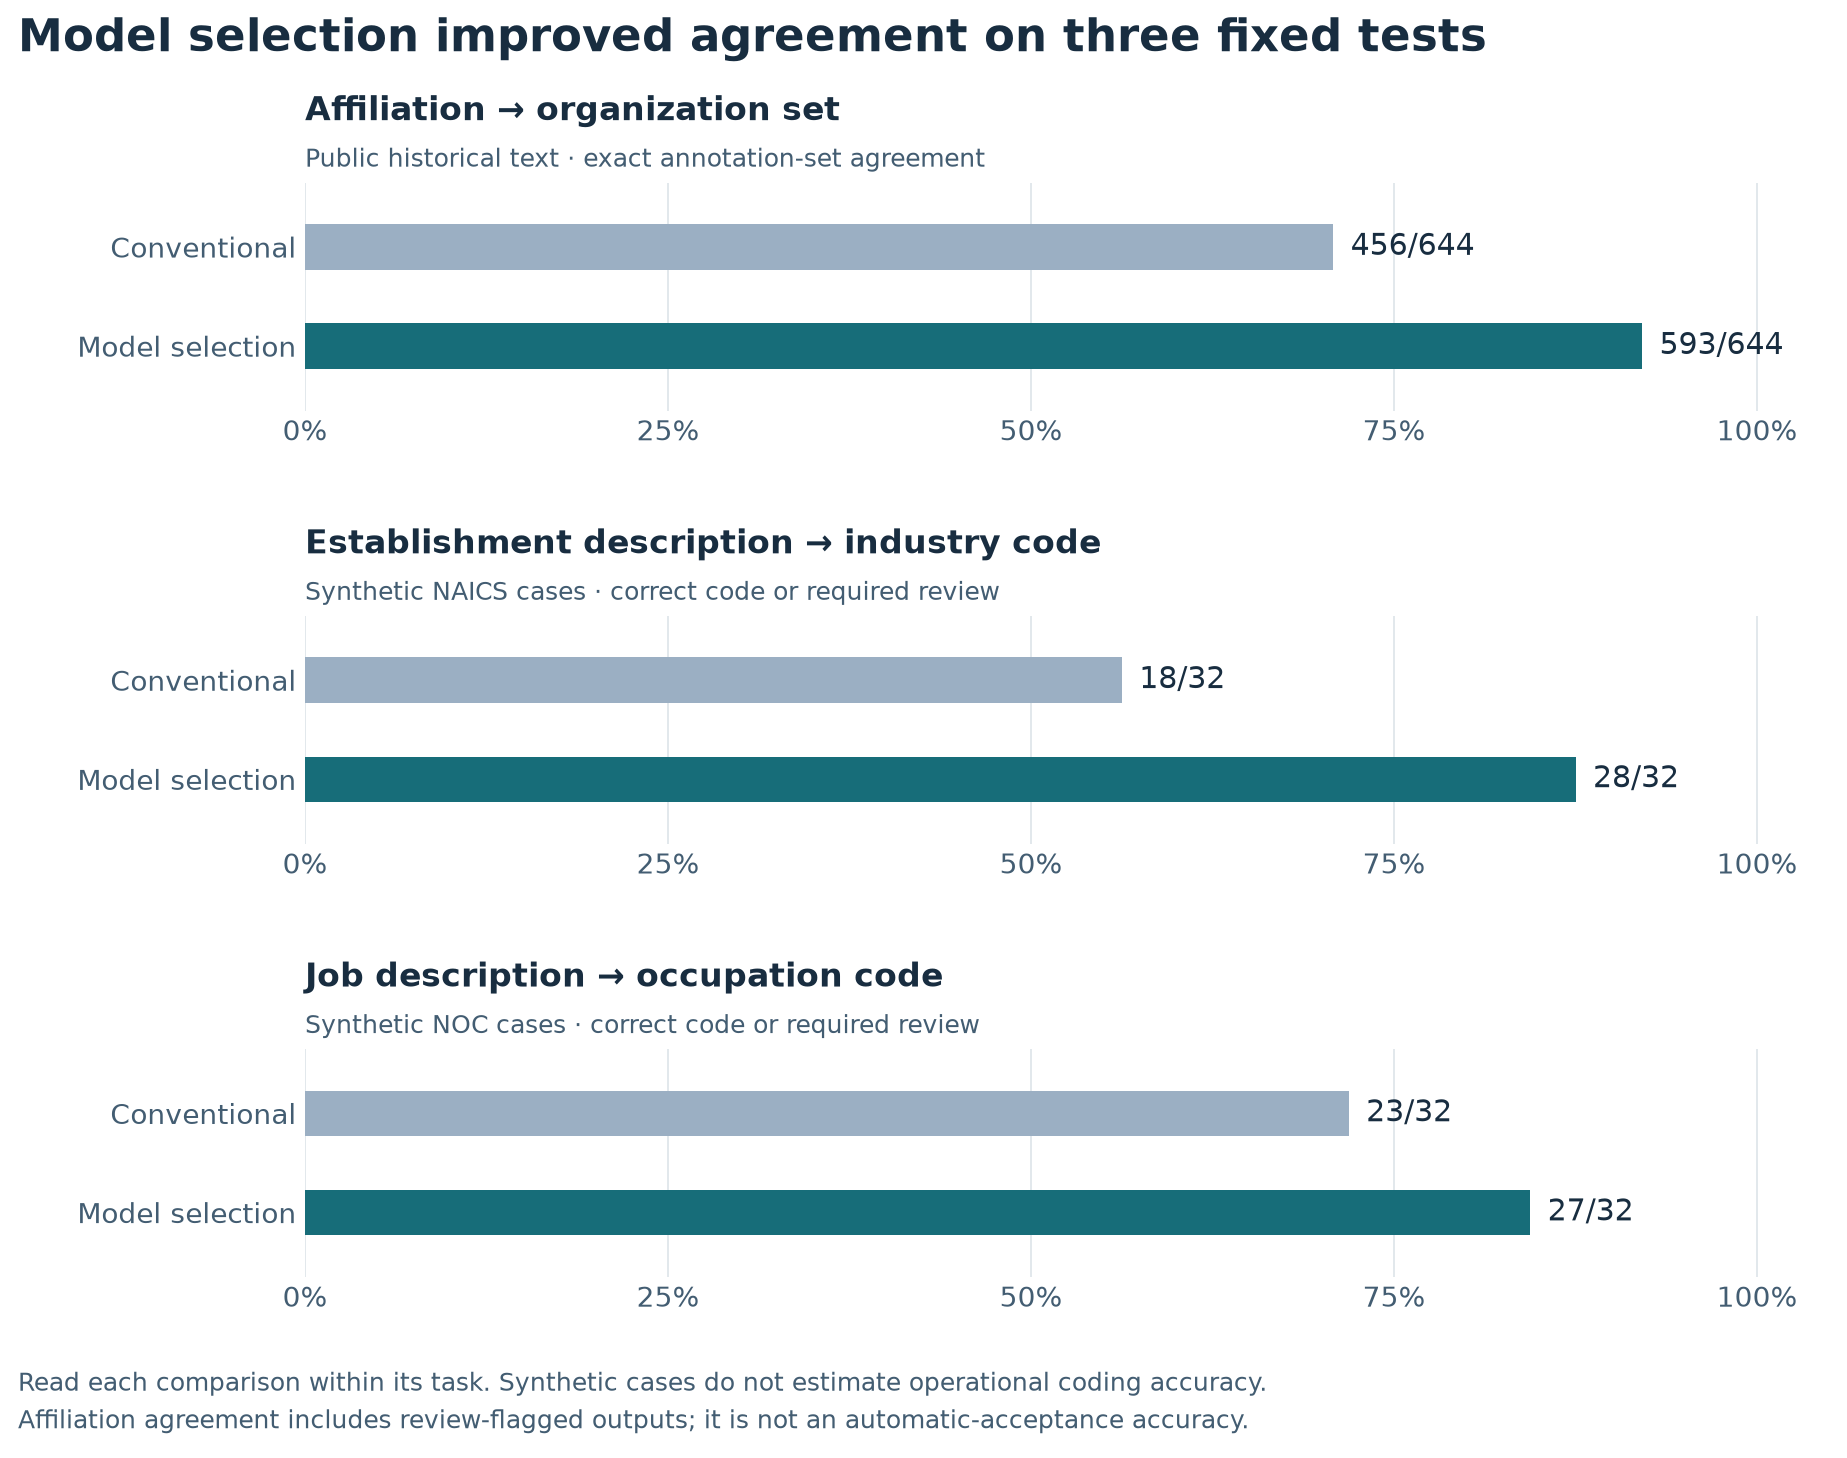

**Figure 1. Selection gains on the fixed tests.** Conventional means the implemented full-resource lexical/rule baseline. Model agreement includes review-flagged affiliation selections and counts invalid required evidence as failure. These comparisons do not rank systems across different tasks or against untested trained classifiers.

## 2. Keep retrieval, interpretation and calculation distinct

The model never receives the reference answers. It sees source text and retrieved candidates, or a request and statistical metadata. Retrieval searches the full eligible reference universe before a small shortlist is sent to the model. A missing true candidate remains an end-to-end failure.

For statistical questions, a model produces a query plan. Deterministic tools select rows and perform decimal arithmetic. The iterative controller may inspect results and revise its plan. A separate reference checks the requested source, population, dates, operation, unit and result.

These runs use a custom candidate selector and a bounded Python tool controller. They measure that implementation. The linked tutorial contains native LOTUS operator examples; the present results are not LOTUS optimizer or `Corpus.agent` benchmarks.

![Top path: source text, full reference retrieval, comparison of rule and model selection, then code, organization set or review. Bottom path: request and metadata, query plan, frozen observations and calculator, then sourced answer or review. Only the iterative arm loops from tool results to planning.](attachment:workflow.png)

**Figure 2. The evaluated information flow.** The numerical arms receive metadata for four known tables. Discovery across 8,270 catalog entries is scored separately. Reference labels enter only after prediction.
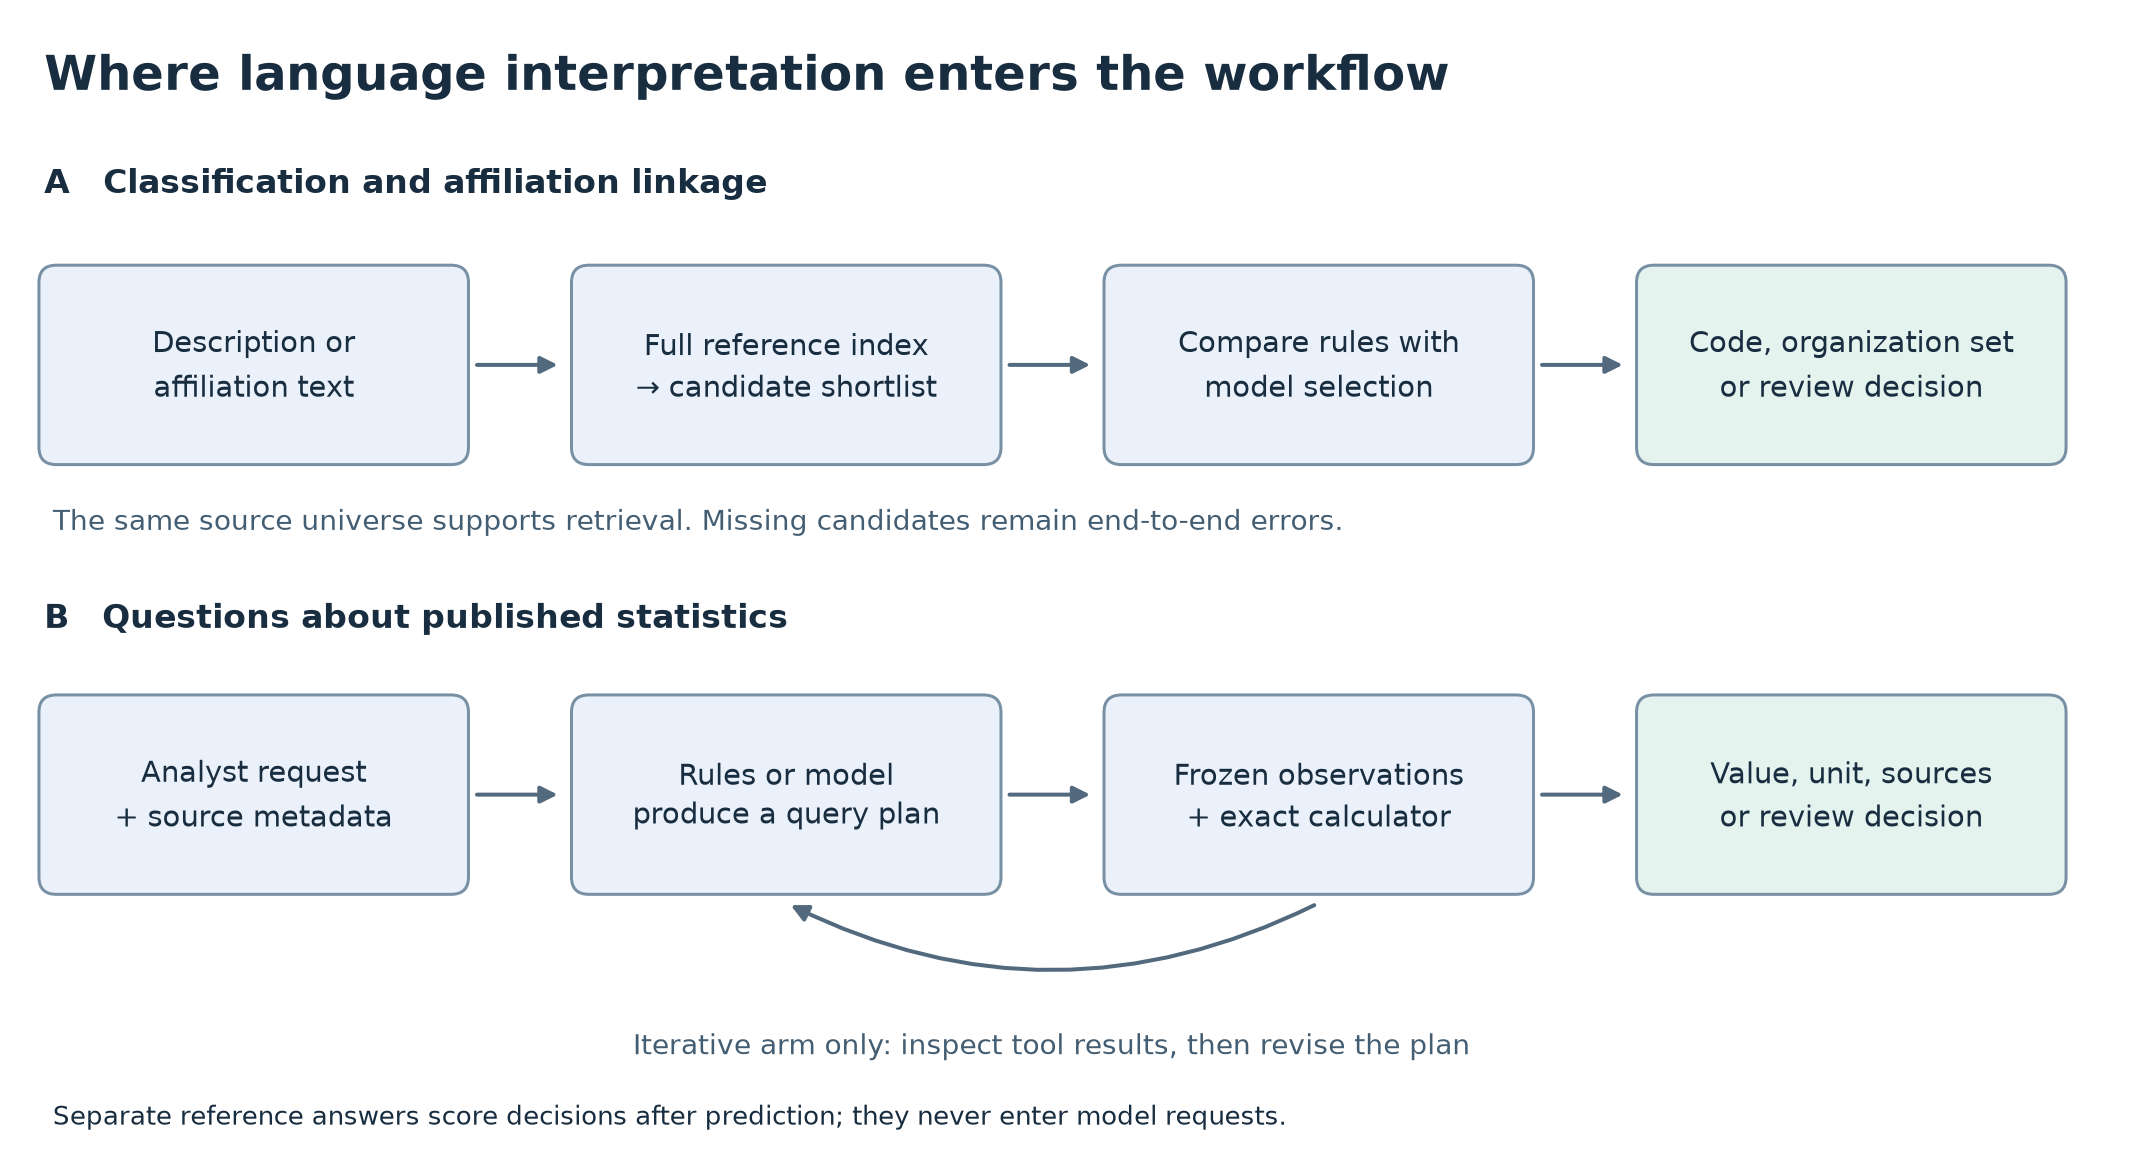

## 3. Organization linkage: more correct sets, an unreliable review flag

The source is [S2AFF's published manual affiliation annotations](https://github.com/allenai/S2AFF/tree/ac8d6b58f42b253821c26fff8b013913317c5c72), paired with the [Research Organization Registry (ROR), dated 16 June 2022](https://zenodo.org/records/6657125). Retrieval searches **102,742 organizations**, including names, aliases, acronyms, multilingual labels and locations. The model receives 25 candidates. All 644 official test rows remain in the denominator; 100 separate validation rows select lexical thresholds and determine whether model testing proceeds.

The target is the complete set of annotated ROR identifiers. Thirty-eight test rows contain historical organization-name labels without a ROR target; 16 have multiple ROR targets. The historical label policy matters. This is a public research-organization benchmark and a proxy for organization-matching work, not a test on an NSO establishment register. Benchmark exposure during pretraining is possible, and the trained S2AFF system is not evaluated here.

In [3]:
l=report['linkage']['test']
table([
 {'Measure':'Valid complete target sets','Result':f"{l['baseline_correct']}/644 → {l['model_correct']}/644"},
 {'Measure':'Paired corrections / regressions','Result':f"{l['corrected']} / {l['regressed']}"},
 {'Measure':'False target assignments','Result':f"{l['baseline_false_target_assignments']} → {l['false_target_assignments']}"},
 {'Measure':'Positive rows with every target in candidates','Result':f"{l['candidate_all_targets_present_nonempty']}/{l['nonempty_target_rows']}"},
 {'Measure':'Model review flags / invalid outputs','Result':f"{l['review_flags']} / {l['domain_invalid']}"},
 {'Measure':'Correct among automatically accepted rows','Result':f"{l['automatic_correct']}/{l['automatic_count']}"}])

Measure,Result
Valid complete target sets,456/644 → 593/644
Paired corrections / regressions,152 / 15
False target assignments,174 → 30
Positive rows with every target in candidates,597/606
Model review flags / invalid outputs,65 / 3
Correct among automatically accepted rows,546/576


The model fixes 152 lexical decisions and breaks 15, for a net gain of 137. False target assignments fall from 174 to 30. This supports contextual selection from candidates; a trained reranker or stronger domain-specific system could recover some of the same gain.

The review flag does not support an automatic-release policy. **Thirty of 576 unflagged outputs are wrong**, including all six unflagged rows with no historical ROR target. The 65 review flags and three invalid outputs therefore cannot be translated into staff time saved.

The following examples are selected by a fixed rule: the first case ID in each outcome category. Complete source-label references and all paired predictions are retained in the [case file](nso-semantic-workflows/results/analysis/linkage-test-cases.json).

In [4]:
import html
def target_names(items):
    return '; '.join(x.get('name') or x['id'] for x in items) or 'No target'
for category,label in [('corrected','A corrected selection'),('wrong_automatic','An incorrect automatic selection')]:
    x=report['linkage']['test']['examples'][category]
    display(HTML(f"<p><b>{label} — {x['id']}</b></p><blockquote>{html.escape(x['text'])}</blockquote>"))
    table([{'Reference':target_names(x['reference_targets']), 'Lexical':target_names(x['baseline_targets']), 'Model':target_names(x['model_targets'])}])

Reference,Lexical,Model
Xidian University,No target,Xidian University


Reference,Lexical,Model
Peking University,Institute for Nuclear Science and Technology,Peking University; Institute of Software


The Peking example illustrates an entity-boundary error: the model adds the separately registered Institute of Software to a university affiliation whose annotation contains Peking University alone. Related names do not establish an additional entity relation.

Exact source-quote validation also rejects otherwise plausible outputs. In the first recorded regression, the model identifies Cornell University correctly but changes a nonbreaking space in its evidence span. That output remains invalid under the frozen contract. A future evidence-extraction design could handle such formatting explicitly; this run is not rescored with a relaxed rule.

## 4. Industry and occupation coding: useful synthetic evidence

The references are [NAICS Canada 2022](https://www.statcan.gc.ca/en/subjects/standard/naics/2022/v1/index) and [NOC 2021](https://www.statcan.gc.ca/en/subjects/standard/noc/2021/indexV1). The full codebooks remain searchable: 923 detailed NAICS classes and 516 NOC unit groups. All official aliases and nonempty duties are available. Exact lookup solves all **48 verbatim controls**, with no model calls.

The 96 synthetic descriptions and their fact bundles were authored by the same language model, then checked against official definitions by a separate language-model review before evaluation. GPT-6 Luna, the evaluated model, did not construct the cases. These are synthetic descriptions without independent human annotation. Each scheme has 12 boundary families; four families form development and eight form test. Related wordings remain in the same family and split. The test for each scheme contains 24 uniquely coded descriptions and eight explicitly incomplete descriptions that require review.

Each model call receives ten query-derived candidates. No true code is inserted into the shortlist. The model must select a supported candidate or request review, with exact source quotations.

In [5]:
table([{'Scheme':scheme.upper(),'Complete decisions':f"{s['model_correct']}/{s['n']}",
        'Unique codes correct':f"{s['unique_target_correct']}/{s['unique_target_n']}",
        'True codes retrieved':f"{s['candidate_target_present']}/{s['unique_target_n']}",
        'Required reviews correct':f"{s['review_correct']}/{s['review_n']}",
        'Invalid outputs':s['domain_invalid']}
       for scheme,s in report['coding']['test']['schemes'].items()])

Scheme,Complete decisions,Unique codes correct,True codes retrieved,Required reviews correct,Invalid outputs
NAICS,28/32,20/24,21/24,8/8,0
NOC,27/32,19/24,22/24,8/8,2


The following are the first corrected test cases by ID within each scheme. They show the two relations on a similar activity: the industry of a veterinary clinic and the occupation of a veterinarian. These examples explain the measured correction; the complete test, including failures, determines the score.

In [6]:
for scheme,label in [('naics','Establishment activity'),('noc','Individual occupation')]:
    x=report['coding']['test']['schemes'][scheme]['examples']['corrected']
    source=next(e for e in x['source_label']['source_evidence'] if e['code']==x['reference']['code'])
    display(HTML(f"<p><b>{label} — {x['id']}</b></p><blockquote>{html.escape(x['text'])}</blockquote>"))
    table([{'Reference':x['reference']['code'] + ' — ' + source['title'],
            'Lexical selection':x['baseline_prediction']['code'],
            'Model selection':x['raw_prediction']['code']}])

Reference,Lexical selection,Model selection
541940 — Veterinary services,622210,541940


Reference,Lexical selection,Model selection
31103 — Veterinarians,32104,31103


NAICS gains 11 correct decisions and loses one; NOC gains four and loses none. Neither scheme emits a unique code on an explicitly unresolved test case. Candidate retrieval excludes three required NAICS codes and two NOC codes, limiting what selection can recover.

The NAICS regression requests review despite a description stating that accounting and auditing are the main activity, with the correct class present. NOC also contains two invalid outputs, including a correct code accompanied by an invented exact quotation. These failures are preserved in the [complete coding cases](nso-semantic-workflows/results/analysis/coding-test-cases.json).

The measured value is additional correct decisions on these authored boundaries. The test does not estimate how often such cases occur, operational coding accuracy, or the time a reviewer saves. Explicit missing-information wording makes the review control easier than naturally ambiguous returns. Independently adjudicated residual descriptions and a trained conventional comparator are the next useful test; another pass over these same test cases is not new evidence.

## 5. School continuity: stop where the baseline suffices

The [NCES Common Core of Data](https://nces.ed.gov/ccd/psu_rev.asp) supplies two annual public school directories. Labels concern the same continuing administrative school identifier. Queries are restricted to schools open and not reconstituted in both years; identifier fields are hidden from matching. The candidate universe contains all 102,229 newer-directory records.

After holding development districts out, the eligible evaluation frame contains 94,586 schools. A probability sample of 300 yields **300 correct conventional matches**. That triggers the predeclared stop, so no school model calls are made. Three hundred successes do not establish perfect population accuracy.

A separate sample of 100 schools where both name and street changed yields **72 correct top-ranked matches**, with 96 true targets in the top ten. That enriched stratum contains 161 schools in the evaluation frame. Its result is not pooled with the probability sample, and it does not override the frozen stop rule. A future study of that rare residual group would need its own sampling and value case.

## 6. Statistical queries: tools do not guarantee the intended calculation

The frozen [Statistics Canada Web Data Service](https://www.statcan.gc.ca/en/developers/wds) corpus contains **401,944 observations from 2023–2025** across labour-force and consumer-price tables. It retains 56 suppressed observations. Each authored question reads 1–12 observations; 401,944 is the available corpus size, not the size of the model's context or a count of rows it reasons over.

Rules, one-shot planning and the iterative controller receive the same four table dictionaries and calculation language. The controller permits at most four model turns and three explicit execution requests. A correct numerical answer must match source rows, requested order, operation, unit and rounding. Required-review cases are scored on the review action and a nonempty reason, not the semantic quality of that explanation.

In [7]:
s=report['statistics']
rows=[{'System':'Rules','Correct / total':f"{s['baseline']['complete_correct']}/32",'Wrong answers without review':s['baseline']['wrong_nonabstaining_answers'],'Review outputs':s['baseline']['review_outputs'],'Model calls':0,'Estimated token price (US$)':'0'}]
for arm,label in [('one_shot','One-shot plan'),('agent','Iterative controller')]:
    x=s[arm]
    rows.append({'System':label,'Correct / total':f"{x['model_correct']}/32",'Wrong answers without review':x['wrong_nonabstaining_answers'],'Review outputs':x['review_outputs'],'Model calls':x['cost']['attempted_calls'],'Estimated token price (US$)':f"{x['cost']['estimated_token_price_usd']:.5f}"})
table(rows)
display(Markdown(f"The controller used **{s['agent_increment']['token_ratio']:.2f}×** the one-shot tokens, with **{s['agent_increment']['additional_complete_answers']}** additional correct answers. It made {s['agent']['execute_calls']} explicit tool queries."))

System,Correct / total,Wrong answers without review,Review outputs,Model calls,Estimated token price (US$)
Rules,29/32,1,9,0,0
One-shot plan,29/32,1,9,32,0.02255
Iterative controller,29/32,3,8,56,0.04189


The controller used **1.85×** the one-shot tokens, with **0** additional correct answers. It made 24 explicit tool queries.

The three systems score 29/32 but fail on different questions. One-shot planning makes three corrections and three regressions relative to rules. The controller likewise makes three corrections and three regressions relative to one-shot planning. Extra interaction produces no net gain and increases wrong answers without review from one to three.

All three controller errors reverse subtraction operands. For example, the request asks for Alberta minus Quebec. The controller supplies the rows in the order that makes the tool calculate Quebec minus Alberta, then accepts the negative result. Decimal arithmetic is correct for that plan; the plan answers the wrong directional question.

Both numerical model arms fail their continuation gate. Further controller tuning stops on this workload. The executor rejects all 56 suppressed rows in offline checks, but no scored question targets one; that is evidence about the tool, not a measured model suppression-handling success rate. [Full numerical cases and traces](nso-semantic-workflows/results/analysis/statistics-agent-test-cases.json) remain available.

## 7. Catalog discovery: selection reaches the retrieval ceiling

The separate discovery test ranks all **8,270 catalog records** using word and character similarity. The model sees only the top 12 titles and the request, without the four numerical dictionaries or an availability flag.

The score measures recovery of the **designated reference source**, not exhaustive relevance. Other tables may answer some requests; those alternatives have not been adjudicated. The reference score cannot label every different table irrelevant.

In [8]:
s=report['statistics']
table([{'Stage':'Lexical first choice','Designated source recovered':'9/24'},
       {'Stage':'Source present among 12 candidates','Designated source recovered':'15/24'},
       {'Stage':'Model selection from those candidates','Designated source recovered':f"{s['discovery']['model_correct']}/24"}])

Stage,Designated source recovered
Lexical first choice,9/24
Source present among 12 candidates,15/24
Model selection from those candidates,15/24


The model recovers six additional designated sources and reaches the fixed shortlist ceiling. All nine remaining reference-source misses occur before model selection. Six result in review; three select alternative tables whose relevance remains unadjudicated. The next useful change is better retrieval evaluated on new requests, not another selection pass over this test.

## 8. Cost, failures and the next decision

Model price is one part of a value case. The ledger records every attempted request, raw response, settings, usage and failure, with retries disabled. Task validation is separate from provider/JSON-schema validation: a parseable response can still quote nonexistent evidence, select an unavailable code or request an invalid calculation.

The pilot prices below use the recorded [GPT-6 Luna token rates](https://developers.openai.com/api/docs/models/gpt-6-luna), checked on 6 October 2026. They are token-price estimates, not invoices, staff costs or operational savings. The shared US$10 reservation ceiling includes headroom; all selected pilot experiments finished below it.

In [9]:
costs=[]
for split in ['val','test']:
    x=report['linkage'][split]['cost'];costs.append({'Run':f'Affiliation {split}','Calls':x['attempted_calls'],'Estimated token price (US$)':f"{x['estimated_token_price_usd']:.5f}"})
for split in ['dev','test']:
    for scheme,x in report['coding'][split]['schemes'].items():
        c=x['cost'];costs.append({'Run':f'{scheme.upper()} {split}','Calls':c['attempted_calls'],'Estimated token price (US$)':f"{c['estimated_token_price_usd']:.5f}"})
for arm in ['one_shot','agent','discovery']:
    c=report['statistics'][arm]['cost'];costs.append({'Run':{'one_shot':'Statistics: one-shot plan','agent':'Statistics: iterative controller','discovery':'Statistics: catalog selection'}[arm],'Calls':c['attempted_calls'],'Estimated token price (US$)':f"{c['estimated_token_price_usd']:.5f}"})
table(costs)
c=report['ledger_snapshot']
display(Markdown(f"**Pilot total: {c['attempted_calls']} model calls; USD {c['estimated_token_price_usd']:.5f} estimated token price; USD {c['reserved_usd']:.5f} reserved.** No pilot requests remain pending."))

Run,Calls,Estimated token price (US$)
Affiliation val,100,0.02050
Affiliation test,644,0.13417
NAICS dev,16,0.00556
NOC dev,16,0.00652
NAICS test,32,0.01089
NOC test,32,0.01232
Statistics: one-shot plan,32,0.02255
Statistics: iterative controller,56,0.04189
Statistics: catalog selection,24,0.00337


**Pilot total: 952 model calls; USD 0.25775 estimated token price; USD 0.93030 reserved.** No pilot requests remain pending.

The initial pilot has zero provider/schema failures, but eight task-invalid outputs: four affiliation, three coding and one numerical plan across development and test. All remain in the scored denominators. Repeated organizations and related synthetic variants make independent-trial population intervals inappropriate; the counts describe these fixed tests.

Carry forward **contextual selection with source evidence**, first on independently labeled residual organization and coding workloads. Evaluate a trained conventional comparator, reference-entity policy, retrieval recall and calibrated review thresholds before estimating release quality. A timed, blinded comparison under the same correctness standard is needed to measure human effort.

Stop **ordinary-school model spending and further numerical-controller tuning** in this pilot. Keep the catalog result as evidence for selection after retrieval, while improving source coverage on fresh requests. Optional two-call coding extraction was not run: the current comparison already identifies retrieval and validation failures without establishing an additional benefit from that extra stage.

The [protocols](nso-semantic-workflows/README.md#follow-the-evidence), [raw request ledger](nso-semantic-workflows/results/api-ledger.jsonl), [all paired cases](nso-semantic-workflows/results/analysis/README.md) and pre-model correction records preserve how each conclusion was obtained. No adverse result was removed to improve the presentation.

## 9. Follow-up: extraction, selection and error trade-offs

**Product selection improves complete decisions and raises false links. Image extraction fails the continuation gate against the strongest conventional comparator.** Both results retain every query, including failed and unresolved outputs. One unchanged product holdout is specified by a post-development amendment; its result is pending.

Splink implements Fellegi–Sunter linkage: it combines field comparisons according to how likely their agreements are among matching and nonmatching records. Expectation–maximization (EM) estimates these distributions from unlabeled records. A declared prior and decision threshold then determine which links to emit. These unlabeled fits can use held-out observed fields (transductive fitting), without their identity labels.

The follow-up separates product identity, image-to-catalog association and historical research-organization identity. These relations are proxies for possible NSO work. They do not measure operational error rates, staff time or savings.

Here, a **complete correct decision** requires an automatic target set or valid NIL that agrees with the reference. Review and failure remain unresolved. The earlier pilot's affiliation score includes valid review-flagged selections. The two scoring definitions are retained and are not pooled.

**Automatic** counts both emitted link sets and valid no-match (NIL) outputs, including wrong decisions. A false link is an emitted record pair absent from the reference; a missed link is a reference pair the system did not emit. True pairs on review or failed queries therefore remain missed. Link counts and query counts differ when a query has several targets.

[Product development](#product-development) · [Image development](#image-development) · [Image holdout](#image-holdout) · [Organizations and controls](#organizations-controls) · [Cost and failures](#followup-cost-failures) · [Amended product holdout](#product-holdout)


![Two panels show the comparison paths. Product records feed lexical or Splink matching, candidate selection from at most 20 retrieved records, or recordwise model extraction followed by fresh Splink. The image panel starts with identical query pixels and separates fixed OCR, model extraction from OCR, model extraction from pixels, and CLIP image–text comparison. Product extraction and both image extraction arms stop after development. Every path produces a target set, NIL, review or failure; reference links enter only the final scoring step.](attachment:product-and-image-comparisons.png)

**Figure 3. Compare extraction and selection using the same observed sources.** Product text enters conventional matching, recordwise model extraction followed by fresh Splink, or selection from at most 20 retrieved candidates. Conventional decisions are also evaluated on that shortlist. Image comparisons start from the same prepared pixels: Tesseract optical character recognition (OCR), model extraction from OCR or pixels, and the pretrained CLIP image–text encoder. The catalog records are shared; CLIP uses title and brand, while lexical and Splink can also use native model numbers. Slashes indicate separate runs. Product extraction and both image extraction arms remain development-only; one amended product selector holdout proceeds. Source labels enter scoring after prediction. Every query retains a target set, NIL (no counterpart), review or failure. The image target is the originating catalog item, with physical-product equivalence unverified.

<a id="product-development"></a>
### 9.1 Product development

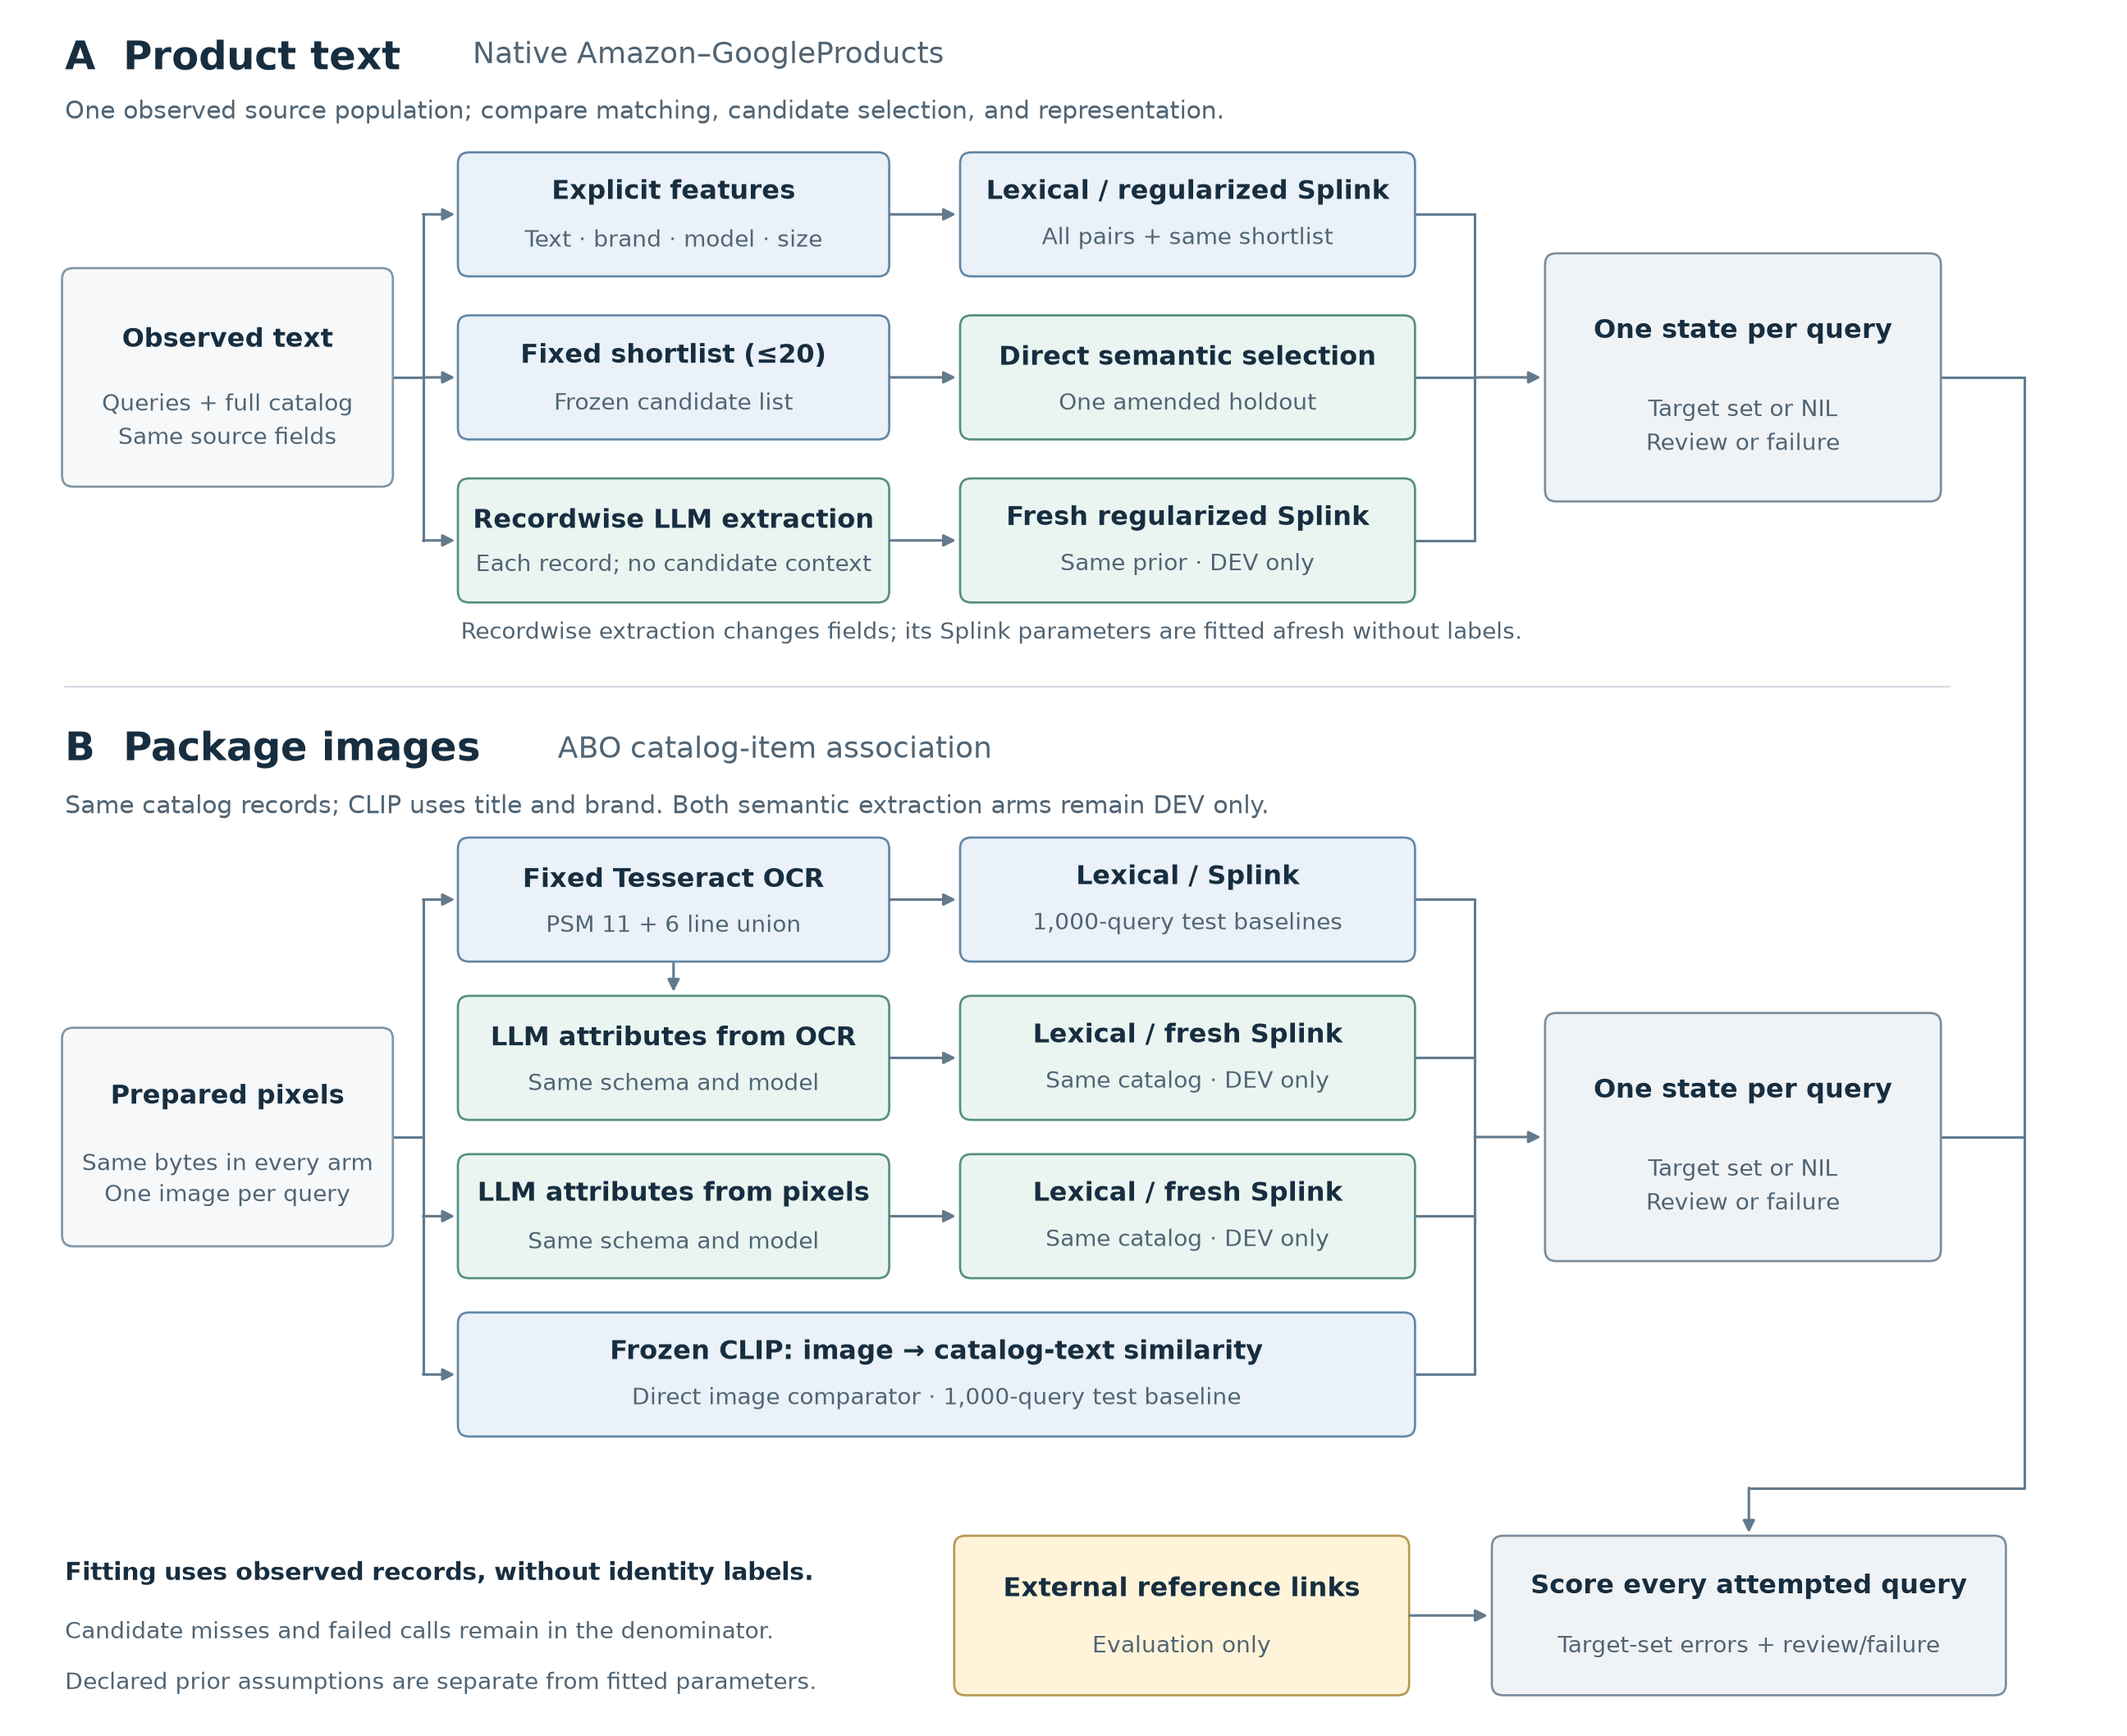

In [10]:
import subprocess
followup_audit = json.loads(subprocess.check_output([sys.executable, str(ROOT / 'adversarial-2026/verify_replay.py')], text=True))
assert followup_audit['status'] == 'verified'

FOLLOWUP = ROOT / 'adversarial-2026'
FOLLOWUP_HASHES = {'products/results/model-development-v1/conventional-primary.json': 'd8a25d37f0a9802d41a995bdcb188b20c06f6d994aa75196c3fe0c08b057772e', 'products/results/model-development-v1/semantic-primary.json': '0bbce3b833cd8e7bf397eb3b68afe02b32ebae66fdfa75693a35af03048b9269', 'images/results/model-development-v1/comparison.json': '8fe51e49767f960d7fdc071b1dafbeea6a0e0baa22d9790dcd48f8379ad76895', 'images/results/free-test-summary.json': '1c1996b638496a45ffce112a3f6d87673e61fd644a4d3b75a4f0e10c3575c6b2', 'organizations/results/development-score.json': 'ed1b2adafa32684484171131752a0acb17a51967a56374d011b30801868919d8'}
def saved_followup(name):
    raw = (FOLLOWUP / name).read_bytes()
    assert hashlib.sha256(raw).hexdigest() == FOLLOWUP_HASHES[name], name
    return json.loads(raw)

product_conventional = saved_followup('products/results/model-development-v1/conventional-primary.json')
product_semantic = saved_followup('products/results/model-development-v1/semantic-primary.json')
image_development = saved_followup('images/results/model-development-v1/comparison.json')
image_free_test = saved_followup('images/results/free-test-summary.json')
organization_development = saved_followup('organizations/results/development-score.json')

def decision_row(label, s):
    return {'Method': label, 'Correct / total': f"{s['correct_complete_decisions']}/{s['queries']}",
            'Automatic': s['automatic_decisions'], 'False links': s['false_links'],
            'Missed links': s['missed_links'], 'Review': s['review_queries'], 'Failed': s['failed_queries']}

table([decision_row(label, group[key]['summary']) for label, group, key in [
    ('Lexical, fixed 0.65', product_conventional, 'lexical_all_pairs'),
    ('Splink, fixed 0.9', product_conventional, 'splink_all_pairs'),
    ('Recordwise extraction → Splink', product_semantic, 'extraction_splink_all_pairs'),
    ('Model candidate selection', product_semantic, 'semantic_selection')]])


Method,Correct / total,Automatic,False links,Missed links,Review,Failed
"Lexical, fixed 0.65",56/144,144,8,99,0,0
"Splink, fixed 0.9",21/144,144,0,143,0,0
Recordwise extraction → Splink,27/144,141,1,136,0,3
Model candidate selection,112/144,136,20,18,8,0


**Product development: 144 queries against 352 catalog records.** Candidate selection makes 63 corrections and seven regressions versus lexical matching. It recovers more complete target sets while false links rise from 8 to 20 and automatic decisions fall from 144 to 136. Its spending gate required at least eight more correct decisions, no extra false links or false-assignment queries, and at least 137 automatic decisions. **The gate fails.** Recordwise extraction followed by Splink also fails: 27 correct versus 56 for lexical.

The fixed candidate union retrieves all targets for 124/125 positive queries. Missing candidates remain end-to-end errors. The unlabeled Splink fits use fixed prior assumptions and thresholds; numerical convergence does not establish calibration. The results compare these implementations and policies, not every conventional matcher. Publisher mappings allow multiple counterparts; benchmark NIL means no supplied counterpart.

[Product methods and source policy](nso-semantic-workflows/adversarial-2026/products/README.md) · [Paired development results](nso-semantic-workflows/adversarial-2026/products/results/model-development-v1/semantic-paired.json) · [Failed gate conditions](nso-semantic-workflows/adversarial-2026/products/results/model-development-v1/development-gates.json)

Prior assumptions materially affect the Splink comparison. At threshold 0.9, fixed assumptions of 0.1, 0.5, 1 and 2 links per query give conventional correct counts of 26, 36, 36 and 47; extraction gives 29, 30, 35 and 46. The primary extraction gain over Splink does not persist across that grid. At lexical threshold 0.5, the conventional rule makes 79 correct decisions with 39 false links. These are descriptive fixed policies, not retuned winners. [Complete conventional grid](nso-semantic-workflows/adversarial-2026/products/results/model-development-v1/conventional-sensitivity.json) · [Extraction grid](nso-semantic-workflows/adversarial-2026/products/results/model-development-v1/semantic-extraction-sensitivity.json)

The first correction and regression by query ID show the source relation:

| Query name | Published reference | Model selection | Lexical / Splink |
|---|---|---|---|
| `quake 4 (mac)` | `aspyr quake iv` | Selects that target | NIL |
| `adobe encore dvd 2.0` | No supplied counterpart | Selects an Adobe Encore DVD 2.0 listing | NIL |

The second case is a disagreement with the publisher mapping. It does not independently prove that the products differ; annotation completeness is a possible explanation. [Development cases](nso-semantic-workflows/adversarial-2026/products/results/model-development-v1/common-query-outcomes.json) retain both outcomes.


A separately frozen conventional reference used the complete Abt–Buy graph: 1,081 queries, 1,092 catalog records and 1,097 reference links. The primary lexical rule made 341 correct sets with 13 false links; Splink made 310 with 455 false links. Both made 1,081 automatic decisions. All fixed sensitivities and source-family intervals remain in the [Abt reference](nso-semantic-workflows/adversarial-2026/products/results/free-abt-reference-v1/reference-summary.md). No semantic model ran on this source, so it is not a replication of a semantic gain.

<a id="image-development"></a>
### 9.2 Image development


In [11]:
image_labels = [('ocr_lexical','OCR → lexical'), ('ocr_splink','OCR → Splink'), ('clip','Frozen CLIP'),
                ('luna_ocr_lexical','Model on OCR → lexical'), ('luna_ocr_splink','Model on OCR → Splink'),
                ('luna_pixel_lexical','Model on pixels → lexical'), ('luna_pixel_splink','Model on pixels → Splink')]
table([decision_row(label, image_development['summaries'][key]) for key, label in image_labels])


Method,Correct / total,Automatic,False links,Missed links,Review,Failed
OCR → lexical,61/80,80,19,19,0,0
OCR → Splink,46/80,80,34,34,0,0
Frozen CLIP,63/80,80,17,17,0,0
Model on OCR → lexical,58/80,74,16,22,5,1
Model on OCR → Splink,55/80,74,19,25,5,1
Model on pixels → lexical,63/80,71,8,17,2,7
Model on pixels → Splink,58/80,71,13,22,2,7


**Image development: 80 queries against 96 catalog records. All four model gates fail against CLIP.** Each needed at least 67 correct decisions and 76 automatic decisions, without additional false assignments. Pixel extraction followed by lexical matching ties CLIP at 63 correct, with eight rather than 17 false links and nine fewer automatic decisions. That is a coverage trade-off.

Extraction improves this OCR/Splink pipeline: the OCR-text arm makes 14 corrections and five regressions; the pixel arm makes 17 corrections and five regressions. Neither exceeds the strongest conventional comparison. No image-model test calls followed the failed gates.

[All image gates and paired comparisons](nso-semantic-workflows/adversarial-2026/images/results/model-development-v1/comparison.json) · [Image methods and source boundary](nso-semantic-workflows/adversarial-2026/images/README.md)

<a id="image-holdout"></a>
### 9.3 Conventional image holdout


In [12]:
free_image_rows=[]
for view, label in [('closed','Closed catalog'),('nil','Designed NIL catalog')]:
    for method, method_label in [('ocr_lexical','OCR → lexical'),('ocr_splink','OCR → Splink'),('clip','CLIP')]:
        s=image_free_test['views'][view]['methods'][method]['summary']
        free_image_rows.append({'View':label, **decision_row(method_label,s)})
table(free_image_rows)


View,Method,Correct / total,Automatic,False links,Missed links,Review,Failed
Closed catalog,OCR → lexical,545/1000,993,448,455,0,7
Closed catalog,OCR → Splink,483/1000,993,510,517,0,7
Closed catalog,CLIP,603/1000,1000,397,397,0,0
Designed NIL catalog,OCR → lexical,420/1000,772,121,471,221,7
Designed NIL catalog,OCR → Splink,276/1000,993,27,721,0,7
Designed NIL catalog,CLIP,260/1000,312,51,541,688,0


The already frozen free image baselines were scored on **1,000 queries** after the model gate closed. The target is the image's originating ABO catalog record. It is not independently adjudicated physical SKU identity. Seven failed/empty OCR observations stay in both denominators.

The closed view forces a top-ranked match when usable evidence supports a valid comparison. The designed NIL view uses different, previously frozen acceptance rules: lexical score/margin 0.30/0.03, CLIP 0.25/0.02 and Splink posterior threshold 0.95. The cross-view change therefore reflects both catalog composition and decision policy.

The designed NIL view removes 200 target associations and introduces 200 distractors. It reuses the same query images, so these views are correlated. False NIL decisions are 231 for lexical, 690 for Splink and one for CLIP; CLIP instead requests review on 688 queries. These thresholds were not retuned. Five test queries have possible cross-split perceptual-image duplicate flags; all remain in the primary result.

[Full free-test results, family intervals and duplicate strata](nso-semantic-workflows/adversarial-2026/images/results/free-test-summary.json)


<a id="organizations-controls"></a>
### 9.4 Organizations and document controls

**The organization and document controls remain separate evidence.** CORDIS development uses 109 queries against all 108,476 historical ROR entries. The fixed lexical rule makes 60 correct automatic decisions with no false links and 49 reviews. Forced top-1 makes 77 correct decisions and 32 false links; Splink makes 41 correct decisions and nine false NIL decisions. Native affiliation sources are separately prepared and unscored.


One sealed free holdout score on 1,065 queries in 1,000 source groups preserves that trade-off:

| Frozen policy | Correct / 1,065 | Automatic | False links | Review |
|---|---:|---:|---:|---:|
| Lexical acceptance rule | 633 | 640 | 6 | 425 |
| Forced top-1 diagnostic | 820 | 1,065 | 245 | 0 |
| Splink EM policy | 323 | 450 | 3 | 615 |

Splink makes 124 false NIL decisions; candidate recall at 40 is 868/873 positive targets. Forced top-1 is a ranking diagnostic, not an operational gate comparator. No fitting or threshold changed; source-group intervals and all errors are in the [free organization evaluation](nso-semantic-workflows/adversarial-2026/organizations/results/free-evaluation-v1/summary.json).

The document controls contain 80 source records, each rendered in four views. All 640 fixed OCR-mode runs succeeded, but no control-model or linkage comparison has run. Price-only views require uncertainty; they do not establish no-match truth. Multiple renderings do not increase the number of source records.

[Organization evidence](nso-semantic-workflows/adversarial-2026/organizations/README.md) · [Document controls](nso-semantic-workflows/adversarial-2026/controls/README.md)

<a id="followup-cost-failures"></a>
### 9.5 Recorded cost and failures


In [13]:
followup_costs=[]
for key,label in [('extraction_splink_all_pairs','Product extraction, both tables'),('semantic_selection','Product selection')]:
    c=product_semantic[key]['summary']['cost']
    followup_costs.append({'Run':label, 'Requests':c['provider_calls'],
                          'Nominal token price (USD )':c['known_nominal_token_price_usd'], 'Reserved (USD )':c['reserved_usd']})
followup_costs.append({'Run':'Image OCR-text and pixel extraction', 'Requests':160,
                      'Nominal token price (USD )':'0.0694894', 'Reserved (USD )':'0.3180990625'})
table(followup_costs)
display(Markdown('**Follow-up development: 800 requests; USD 0.1491891 nominal token price; USD 0.985343125 reserved.** '
                 'Shared catalog extraction is counted once. These figures exclude the earlier pilot and pending product holdout. '
                 'They price recorded model usage, not hardware, human review or production operation.'))


Run,Requests,Nominal token price (USD ),Reserved (USD )
"Product extraction, both tables",496,0.0521001,0.44698421875
Product selection,144,0.0275996,0.22025984375
Image OCR-text and pixel extraction,160,0.0694894,0.3180990625


**Follow-up development: 800 requests; USD 0.1491891 nominal token price; USD 0.985343125 reserved.** Shared catalog extraction is counted once. These figures exclude the earlier pilot and pending product holdout. They price recorded model usage, not hardware, human review or production operation.

The product extractor has **33 invalid record extractions out of 496**: 29 schema rejections and four source-quote validation failures. The 29 rejected responses arrived and ended normally; they are not established transport failures. Three failed records are left queries; the remaining invalid records also affect catalog evidence. The image extractor has **eight invalid outputs out of 160**: six schema rejections and two length-terminated invalid outputs. No output repair or retry was applied.

Request failure, insufficient evidence, review and valid NIL are different events. Every query remains in the complete-decision denominator, and review is not counted as correct NIL. These failure counts belong to the follow-up, while the earlier pilot's ledger and failure accounting remain intact.

[Product extraction audit](nso-semantic-workflows/adversarial-2026/products/results/model-development-v1/extraction-audit.json) · [Image rejection audit](nso-semantic-workflows/adversarial-2026/images/results/model-development-v1/error-audit.json)


<a id="product-holdout"></a>
### 9.6 Amended product holdout

**Pending: one unchanged product holdout under an explicit amendment.** The original gate remains failed. The post-development amendment changes the spending decision once to measure the selection trade-off on 1,219 queries against 2,874 records. It keeps the prompt, model, candidates, comparator policies and outcome definitions fixed, with at most USD 0.964 reserved. This is an allowance, not recorded expenditure.

The result will report correct target sets, false and missed links, false assignments, NIL errors, review, failure and coverage. No unrun result is implied here. Product identity and image association remain research proxies; a future NSO decision needs its own entity policy, independent labels, error costs and measured review effort.

[Post-development amendment and stopping rule](nso-semantic-workflows/adversarial-2026/contracts/product-tradeoff-amendment-v1.json)
